# 6. Model Validation on New Incoming Data — Evaluation, Hybrid Health Score & Drift Analysis

This phase forms the model validation and comparison layer of the sensor analytics framework.
Its main goal is to apply all previously trained models to fresh incoming vessel data,
evaluate their generalization ability, and prepare the foundation for a dynamic hybrid health model

---

### **Objectives**

* Perform thorough EDA and preprocessing on the new dataset (timestamps, missing data, variability, smoothing, resampling).
* Run the Autoencoder, GRU forecaster and optional anomaly models on the new data.
* Compare their outputs directly on the same dataset for a fair evaluation.
* Generate a combined Hybrid Health Score (HHS) using weighted or learned blending.
* Assess distributional data drift between old (training) and new datasets.
* Identify whether retraining, fine-tuning, or reweighting is needed for the next iteration.

---

### **Why This Matters**

While the previous phase established strong baseline models using historical data,
this phase ensures that the system can adapt and remain reliable when new data arrives.
By evaluating multiple models on the same input stream, the pipeline reveals:

* How well each model generalizes
* Where each model fails or overfits
* How their strengths can be combined
* Whether new patterns indicate sensor drift or environmental shifts

This comparison layer enables the framework to move from isolated model usage to a
robust, hybrid, dynamically-adaptive health scoring system
that improves as more data arrives.

Once validated, the Hybrid Health Score (HHS) and drift analysis provide the backbone for
real-time reliability tracking, early fault warnings, and future self-adjusting anomaly detection.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.feature_selection import mutual_info_regression
from statsmodels.tsa.stattools import grangercausalitytests
from itertools import combinations
import os
import warnings
from datetime import datetime
import glob
import json
from datetime import datetime, timedelta
import io
import datashader as ds
import datashader.transfer_functions as tf
from datashader.mpl_ext import dsshow
import colorcet
import hvplot.pandas
import holoviews as hv
from holoviews.operation.datashader import datashade, dynspread
hv.extension('bokeh')
import missingno as msno
import random
import networkx as nx
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")


In [ ]:
# Function to merge sensor data with metadata and save as CSV but each sensor is treated separately
def merge_sensor_with_meta(data_dir="data", output_dir="merged_csv"):
    import os
    import pandas as pd
    import json
    import io

    os.makedirs(output_dir, exist_ok=True)

    for folder in os.listdir(data_dir):
        if folder.endswith("_PRIM"):
            sensor_id = folder
            meta_path = os.path.join(data_dir, folder + ".meta")
            prim_dir = os.path.join(data_dir, folder)

            # Load .meta file
            with open(meta_path, 'r', encoding='utf-8') as f:
                meta = json.load(f)
            export_meta = meta.get("ExportMetaData", {})
            point_meta = meta.get("PointMetaData", {})

            all_data = []
            # Iterate through all .txt files and collect data
            for txt_file in os.listdir(prim_dir):
                if not txt_file.endswith(".txt"):
                    continue
                file_path = os.path.join(prim_dir, txt_file)
                # Read data, skip header lines starting with ';'
                with open(file_path, 'r') as f:
                    lines = f.readlines()
                data_lines = [line for line in lines if not line.lstrip().startswith(';')]
                # Parse data into DataFrame
                df = pd.read_csv(
                    io.StringIO(''.join(data_lines)),
                    names=["Timestamp", "Value", "ValueStatus"]
                )
                # Attach all ExportMetaData fields
                for k, v in export_meta.items():
                    df[k] = v
                # Attach all PointMetaData fields
                for k, v in point_meta.items():
                    df[k] = v
                # Also keep sensor_id for traceability
                df["sensor_id"] = sensor_id
                all_data.append(df)

            # Merge all txt files for this sensor into one DataFrame
            if all_data:
                combined_df = pd.concat(all_data, ignore_index=True)
                combined_df.sort_values("Timestamp", inplace=True)
                combined_df.reset_index(drop=True, inplace=True)
                out_path = os.path.join(output_dir, f"{sensor_id}.csv")
                combined_df.to_csv(out_path, index=False)

In [7]:
data_dir = "/Users/yasmine/Kongsberg/data/raw"
output_dir = "/Users/yasmine/Kongsberg/data/processed/merged_csv"

In [9]:
merge_sensor_with_meta(data_dir, output_dir)

In [11]:
merged_dir = "/Users/yasmine/Kongsberg/data/processed/merged_csv"
csv_files = [f for f in os.listdir(merged_dir) if f.endswith(".csv")]

dfs = []
for file in csv_files:
    df = pd.read_csv(
        os.path.join(merged_dir, file),
        parse_dates=['Timestamp', 'ExportDate', 'FirstRecordedTimestamp', 'LastRecordedTimestamp'],
        low_memory=False
    )
    dfs.append(df)

merged_df = pd.concat(dfs, ignore_index=True)
merged_df.to_csv("/Users/yasmine/Kongsberg/data/test_data.csv", index=False)

print(f"Merged {len(csv_files)} files into /Users/yasmine/Kongsberg/data/test_data.csv")

Merged 45 files into /Users/yasmine/Kongsberg/data/test_data.csv


## Data Overview

We'll analyze the sensor data stored in individual files to:
1. Get overall dataset properties
2. Understand sensor distributions
3. Examine data quality metrics
4. Identify patterns and anomalies

In [5]:
# Load merged data
df = pd.read_csv(
    "/Users/yasmine/Kongsberg/data/test_data.csv",
    parse_dates=['Timestamp', 'ExportDate', 'FirstRecordedTimestamp', 'LastRecordedTimestamp']
)

In [6]:
# Data overview
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5729769 entries, 0 to 5729768
Data columns (total 39 columns):
 #   Column                  Dtype              
---  ------                  -----              
 0   Timestamp               object             
 1   Value                   object             
 2   ValueStatus             float64            
 3   ExportDate              datetime64[ns, UTC]
 4   ExportVersion           object             
 5   ExportType              int64              
 6   TimestampPrecisionType  int64              
 7   ExportFrom              object             
 8   ExportTo                object             
 9   IncludeBadValues        bool               
 10  TotalEvents             int64              
 11  TotalGoodValues         int64              
 12  TotalBadValues          int64              
 13  LowestFrequency         float64            
 14  HighestFrequency        float64            
 15  AverageFrequency        float64            
 16  

In [7]:
print(df.shape)

(5729769, 39)


## EDA

In [34]:
df = pd.read_csv("/Volumes/YASMINE/KONGSBERG/merged2_csv/LNGMEGIA.CT005.01_Meas1_PRIM.csv",)

In [58]:
def eda_large(df, value_col='Value', time_col='Timestamp', n_splits=6):
    """
    Perform Exploratory Data Analysis on large time-series datasets safely.
    - Splits data into N chunks for manageable plotting
    - Offers alternatives for full-data visualization without sampling
    """
    print("=== EDA for Large Dataset ===")
    print(f"Total Rows: {len(df):,}")

    # --- Convert datatypes ---
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
    df[value_col] = pd.to_numeric(df[value_col], errors='coerce')
    df = df.dropna(subset=[time_col, value_col]).sort_values(by=time_col)

    # --- Clean data ---
    df_plot = df.copy()
    df_plot['Timestamp'] = pd.to_datetime(df_plot['Timestamp'], errors='coerce')
    df_plot['Value'] = pd.to_numeric(df_plot['Value'], errors='coerce')
    df_plot = df_plot.dropna(subset=['Timestamp', 'Value']).sort_values('Timestamp')

    # --- Full Time-Series Plot (No Chunking) ---
    plt.figure(figsize=(18, 5))
    plt.plot(df_plot['Timestamp'], df_plot['Value'], lw=0.4, color='navy')
    plt.title("Full Time-Series (No Chunking)")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.tight_layout()
    plt.show()


    # --- Summary statistics ---
    print("\n=== GLOBAL STATISTICS ===")
    display(df[value_col].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

    # --- Histogram ---
    plt.figure(figsize=(8, 4))
    sns.histplot(df[value_col], bins=100, kde=True, color='steelblue')
    plt.title("Value Distribution (All Data)")
    plt.tight_layout()
    plt.show()

    # --- Boxplot ---
    plt.figure(figsize=(5, 4))
    sns.boxplot(y=df[value_col], color='lightblue')
    plt.title("Value Boxplot (All Data)")
    plt.tight_layout()
    plt.show()


=== EDA for Large Dataset ===
Total Rows: 40,336


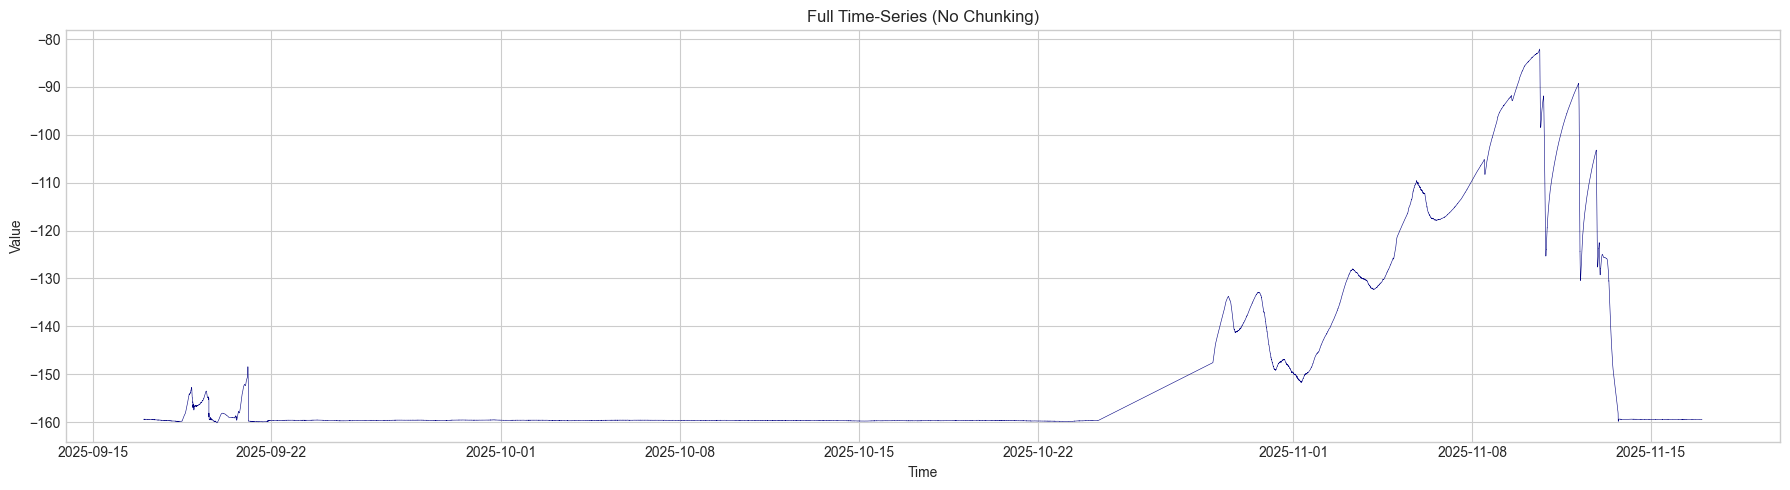


=== GLOBAL STATISTICS ===


count    40336.000000
mean      -141.607392
std         23.057757
min       -160.150000
1%        -159.850000
5%        -159.730000
25%       -159.620000
50%       -157.450000
75%       -125.770000
95%        -93.777492
99%        -84.753490
max        -82.090000
Name: Value, dtype: float64

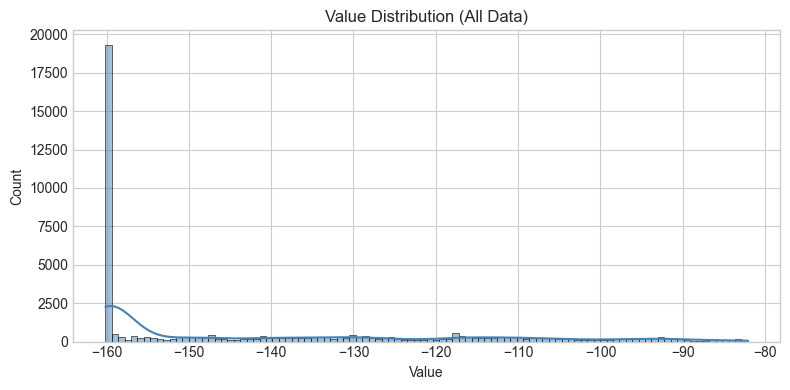

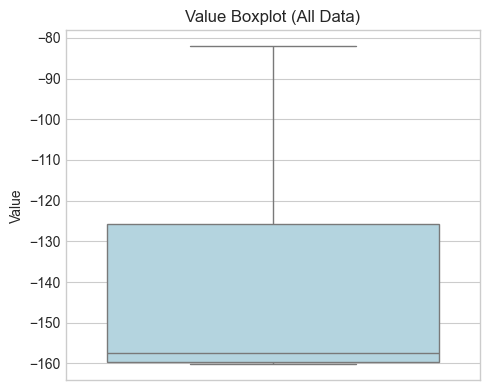

In [ ]:
eda_large(df)

1. Full Time Series (No Chunking)

The full time-series shows long periods of stable low readings followed by a sharp rise and high-variability fluctuations near the end of the timeline.

2. Value Distribution 

The value distribution is heavily right-skewed, with most readings clustered around −160 and progressively fewer measurements at higher values.

3. Boxplot

The boxplot shows a very compressed lower distribution around −160 and a wide whisker upward, indicating extreme positive outliers relative to the dominant baseline.

In [39]:
def eda_datashader_full(df, value_col='Value', time_col='Timestamp', category_cols=None, output_name='eda_full'):
    """
    Full visual exploratory data analysis without modifying cleaned data.
    Includes:
    - Full Datashader visualization
    - Segment-wise zooms
    - Distribution plots
    - Whisker (box) & quantile plots
    - Outlier detection (Z-score and IQR)
    - Category-based distributions
    """

    print("=== FULL EDA START ===")
    print(f"Rows: {len(df):,} | Columns: {len(df.columns)}")

    # --- Basic Info ---
    print("\n=== BASIC INFO ===")
    print(df.info())
    print("\n=== SUMMARY STATISTICS ===")
    display(df.describe(include='all').T)

    # === CLEAN VALUE COLUMN FOR NUMERIC OPERATIONS ===
    print("\n=== CLEANING VALUE COLUMN FOR NUMERIC OPERATIONS ===")
    df[value_col] = pd.to_numeric(df[value_col], errors='coerce')
    non_numeric_count = df[value_col].isna().sum()
    print(f"Converted {non_numeric_count:,} non-numeric entries to NaN.")

    # === DATASHADER VISUALIZATIONS ===
    print("\nGenerating Datashader full-series plot...")
    try:
        # Convert timestamp to numeric
        df["time_numeric"] = pd.to_datetime(df[time_col], errors='coerce').astype('int64') / 1e9

        cvs = ds.Canvas(plot_width=2500, plot_height=500)
        agg = cvs.line(df, x="time_numeric", y=value_col)
        img = tf.shade(agg, cmap=["#c6dbef", "#08306b"], how="linear")
        final_img = tf.set_background(img, "white").to_pil()

        # Zoomed segments
        n_segments = 5
        seg_len = len(df) // n_segments

        for i in range(n_segments):
            seg = df.iloc[i*seg_len:(i+1)*seg_len]
            cvs_seg = ds.Canvas(plot_width=1500, plot_height=300)
            agg_seg = cvs_seg.line(seg, x="time_numeric", y=value_col)
            img_seg = tf.shade(agg_seg, cmap=["#9ecae1", "#08519c"], how="linear")
            tf.set_background(img_seg, "white").to_pil().save(f"{output_name}_segment{i+1}.png")

        print(f"Saved {n_segments} zoomed segment plots.")

    except Exception as e:
        print("Datashader visualization failed:", e)

    # === DISTRIBUTION PLOTS ===
    print("\nGenerating distributions and boxplots...")
    plt.figure(figsize=(10, 4))
    sns.histplot(df[value_col], bins=80, kde=True, color='steelblue')
    plt.title("Value Distribution")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5, 4))
    sns.boxplot(y=df[value_col], color='#a6cee3')
    plt.title("Boxplot (Whisker Plot)")
    plt.tight_layout()
    plt.show()

    # === QUANTILE PLOT ===
    print("\nQuantile Distribution Plot...")
    quantiles = np.linspace(0, 1, 100)
    values = np.quantile(df[value_col].dropna(), quantiles)

    plt.figure(figsize=(8, 4))
    plt.plot(quantiles, values, color='navy')
    plt.xlabel('Quantile')
    plt.ylabel(value_col)
    plt.title("Quantile Plot")
    plt.tight_layout()
    plt.show()

    # === OUTLIER DETECTION ===
    print("\nOutlier detection (Z-score & IQR)...")
    series = df[value_col].dropna()

    z_scores = np.abs(stats.zscore(series))
    iqr = np.percentile(series, 75) - np.percentile(series, 25)
    lower = np.percentile(series, 25) - 1.5 * iqr
    upper = np.percentile(series, 75) + 1.5 * iqr

    z_outliers = np.sum(z_scores > 3)
    iqr_outliers = np.sum((series < lower) | (series > upper))

    print(f"Z-score Outliers: {z_outliers:,}")
    print(f"IQR Outliers: {iqr_outliers:,}")

    plt.figure(figsize=(8, 4))
    sns.histplot(series, bins=80, color='lightgray', label='Data Range')
    plt.axvline(upper, color='red', ls='--', label='Upper IQR Bound')
    plt.axvline(lower, color='red', ls='--', label='Lower IQR Bound')
    plt.legend()
    plt.title("Outlier Boundaries (IQR Method)")
    plt.tight_layout()
    plt.show()

    # === CATEGORY DISTRIBUTIONS ===
    if category_cols:
        print("\nCategory-based Distributions...")
        for col in category_cols:
            if col in df.columns:

                plt.figure(figsize=(8, 4))
                sns.boxplot(x=col, y=value_col, data=df, palette='Blues')
                plt.title(f"{value_col} by {col}")
                plt.tight_layout()
                plt.savefig(f"{output_name}_{col}_boxplot.png", dpi=150)
                plt.show()

                plt.figure(figsize=(8, 4))
                sns.violinplot(x=col, y=value_col, data=df, inner="quart", palette='Blues')
                plt.title(f"Distribution by {col} (Violin Plot)")
                plt.tight_layout()
                plt.show()

    print("\n=== EDA COMPLETE ===")


=== FULL EDA START ===
Rows: 40,367 | Columns: 39

=== BASIC INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40367 entries, 0 to 40366
Data columns (total 39 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               40367 non-null  object 
 1   Value                   40367 non-null  object 
 2   ValueStatus             40337 non-null  float64
 3   ExportDate              40367 non-null  object 
 4   ExportVersion           40367 non-null  object 
 5   ExportType              40367 non-null  int64  
 6   TimestampPrecisionType  40367 non-null  int64  
 7   ExportFrom              40367 non-null  object 
 8   ExportTo                40367 non-null  object 
 9   IncludeBadValues        40367 non-null  bool   
 10  TotalEvents             40367 non-null  int64  
 11  TotalGoodValues         40367 non-null  int64  
 12  TotalBadValues          40367 non-null  int64  
 13  LowestFrequency      

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,40367,40338,; LNGMEGIA.CT005.01/Meas1/PRIM,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Value,40367.0,7750.0,-159.59,1441.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ValueStatus,40337.0,NaN,NaN,NaN,0.999975,0.004979,0.0,1.0,1.0,1.0,1.0
ExportDate,40367,1,2025-11-17T08:29:22.7646088+00:00,40367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ExportVersion,40367,1,1.1.3,40367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ExportType,40367.0,NaN,NaN,NaN,2.0,0.0,2.0,2.0,2.0,2.0,2.0
TimestampPrecisionType,40367.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
ExportFrom,40367,1,2025-09-17T00:00:00Z,40367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ExportTo,40367,1,2025-11-16T23:59:59.9999999Z,40367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IncludeBadValues,40367,1,True,40367,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== CLEANING VALUE COLUMN FOR NUMERIC OPERATIONS ===
Converted 31 non-numeric entries to NaN.

Generating Datashader full-series plot...
Saved 5 zoomed segment plots.

Generating distributions and boxplots...


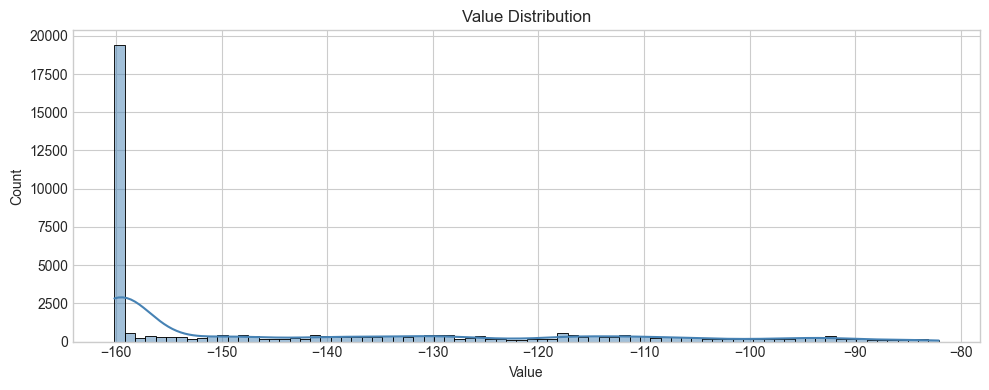

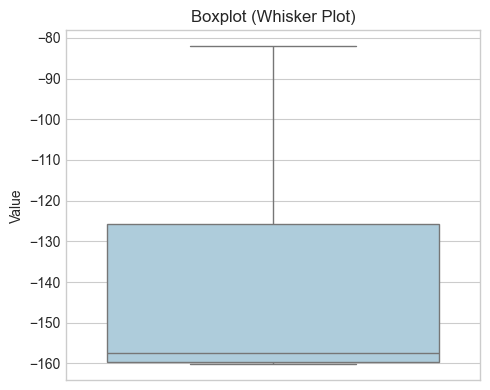


Quantile Distribution Plot...


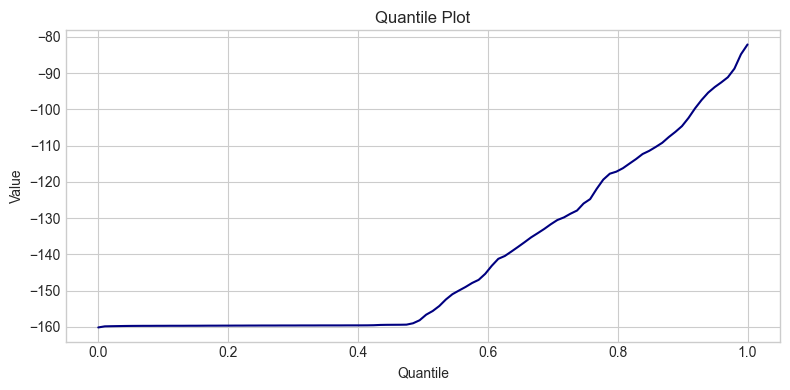


Outlier detection (Z-score & IQR)...
Z-score Outliers: 0
IQR Outliers: 0


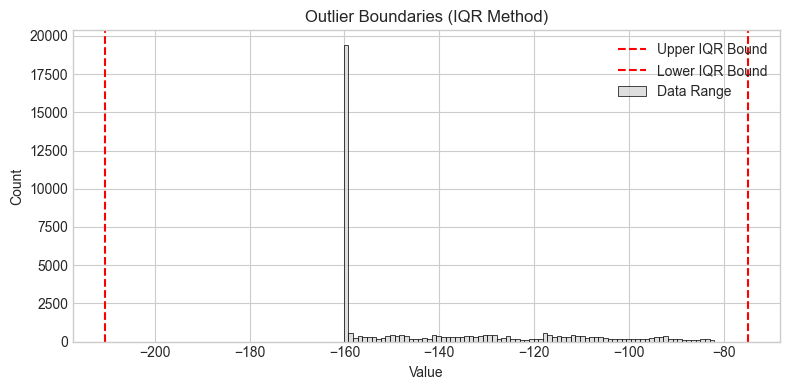


=== EDA COMPLETE ===


In [40]:
eda_datashader_full(df)

1. Value Distribution (Redo Plot)

The second distribution plot confirms the same strong peak at −160 and a long tail toward −80, reinforcing the multimodal or multi-state nature of the sensor readings.

2. Boxplot (Whisker Plot)

This whisker plot again highlights a narrow dense cluster near −160 and a long upward range, showing that unusual high values dominate the outlier structure.

3. Quantile Plot

The quantile plot shows a flat region at the lower end followed by a smooth upward curve, confirming that most data are concentrated at the minimum with gradual spread above the 50th percentile.

4. Outlier Boundaries (IQR Method)

The IQR plot shows that almost the entire dataset lies between −160 and −80, with no values breaching the calculated outlier thresholds, indicating the distribution is wide but not statistically extreme.

In [41]:
print(df.columns)
print(df.dtypes)

Index(['Timestamp', 'Value', 'ValueStatus', 'ExportDate', 'ExportVersion',
       'ExportType', 'TimestampPrecisionType', 'ExportFrom', 'ExportTo',
       'IncludeBadValues', 'TotalEvents', 'TotalGoodValues', 'TotalBadValues',
       'LowestFrequency', 'HighestFrequency', 'AverageFrequency',
       'FirstRecordedTimestamp', 'LastRecordedTimestamp', 'ExportedFromServer',
       'PiPointName', 'PointSource', 'PointType', 'DigitalSet',
       'ExceptionDeviation', 'ExceptionMaximum', 'ExceptionMinimum',
       'ExceptionPercentage', 'Descriptor', 'Span', 'Zero', 'EngineeringUnits',
       'Compressing', 'Step', 'CompressionDeviation', 'CompressionMaximum',
       'CompressionMinimum', 'CompressionPercentage', 'SanitizedFilename',
       'sensor_id', 'time_numeric'],
      dtype='object')
Timestamp                  object
Value                     float64
ValueStatus               float64
ExportDate                 object
ExportVersion              object
ExportType                  int64


In [42]:
# ---- Load Data ----
df = df.copy()

# Detect numeric and categorical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

Numeric columns: ['Value', 'ValueStatus', 'ExportType', 'TimestampPrecisionType', 'TotalEvents', 'TotalGoodValues', 'TotalBadValues', 'LowestFrequency', 'HighestFrequency', 'AverageFrequency', 'DigitalSet', 'ExceptionDeviation', 'ExceptionMaximum', 'ExceptionMinimum', 'ExceptionPercentage', 'Span', 'Zero', 'EngineeringUnits', 'Compressing', 'Step', 'CompressionDeviation', 'CompressionMaximum', 'CompressionMinimum', 'CompressionPercentage', 'time_numeric']
Categorical columns: ['Timestamp', 'ExportDate', 'ExportVersion', 'ExportFrom', 'ExportTo', 'IncludeBadValues', 'FirstRecordedTimestamp', 'LastRecordedTimestamp', 'ExportedFromServer', 'PiPointName', 'PointSource', 'PointType', 'Descriptor', 'SanitizedFilename', 'sensor_id']


Text(0, 0.5, 'Percent Missing')

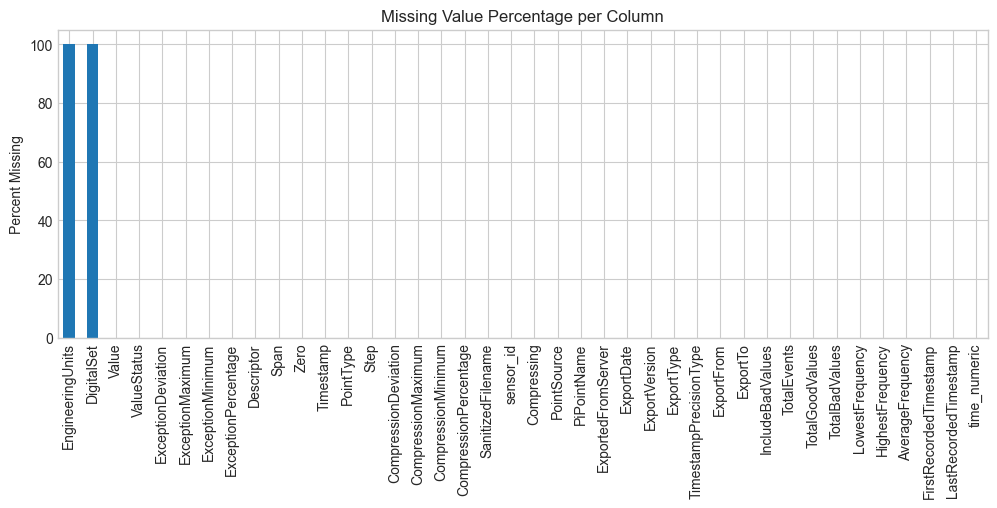

In [43]:
missing_summary = df.isna().mean().sort_values(ascending=False) * 100
missing_summary.plot(kind='bar', figsize=(12,4), title='Missing Value Percentage per Column')
plt.ylabel('Percent Missing')

The missing-value chart shows that almost all columns are fully populated except for ‘EngineeringUnits’ and ‘DigitalSet,’ which are entirely missing.

Invalid timestamps converted to NaT: 30


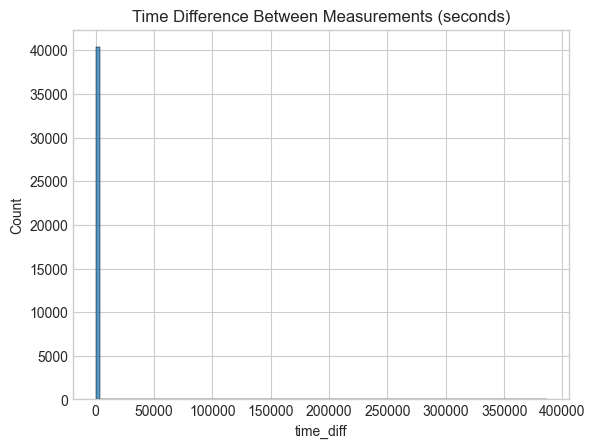

In [44]:
# Convert timestamp column
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
num_invalid = df['Timestamp'].isna().sum()
print(f"Invalid timestamps converted to NaT: {num_invalid:,}")

# Compute time differences
df['time_diff'] = df['Timestamp'].diff().dt.total_seconds()

# Plot
sns.histplot(df['time_diff'], bins=100)
plt.title("Time Difference Between Measurements (seconds)")
plt.show()


The time-difference histogram reveals an overwhelming number of near-zero gaps between measurements, indicating the sensor logs data at a highly consistent interval with occasional large jumps.

<Axes: >

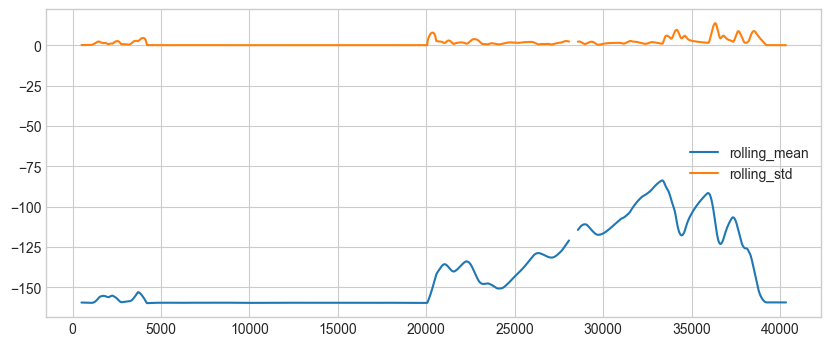

In [45]:
df['rolling_mean'] = df['Value'].rolling(window=500).mean()
df['rolling_std'] = df['Value'].rolling(window=500).std()
df[['rolling_mean', 'rolling_std']].plot(figsize=(10,4))

The rolling mean captures long-term sensor level shifts while the rolling standard deviation reveals periods of high short-term variability.

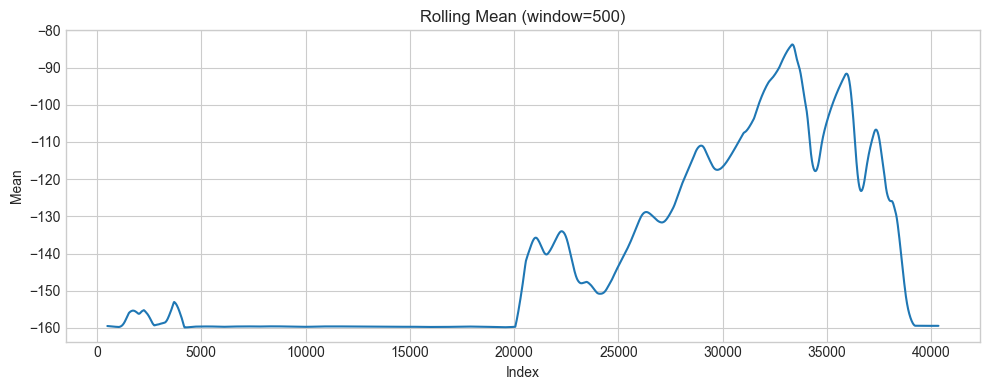

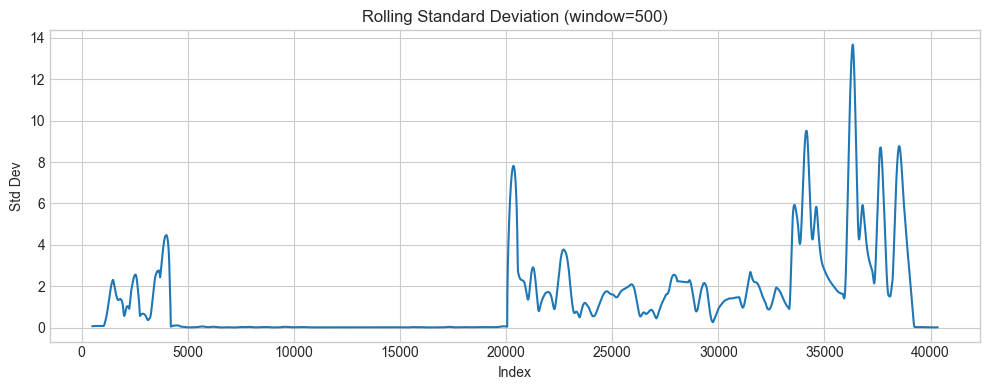

In [46]:
df['rolling_mean'] = df['Value'].rolling(window=500).mean()
df['rolling_std'] = df['Value'].rolling(window=500).std()

# Plot rolling mean
plt.figure(figsize=(10,4))
sns.lineplot(data=df['rolling_mean'])
plt.title("Rolling Mean (window=500)")
plt.xlabel("Index")
plt.ylabel("Mean")
plt.tight_layout()
plt.show()

# Plot rolling std
plt.figure(figsize=(10,4))
sns.lineplot(data=df['rolling_std'])
plt.title("Rolling Standard Deviation (window=500)")
plt.xlabel("Index")
plt.ylabel("Std Dev")
plt.tight_layout()
plt.show()


- The rolling mean shows stable low values for long periods followed by a clear sustained rise in sensor readings.
- The rolling standard deviation highlights intervals of turbulence where short-term fluctuations spike significantly.

In [47]:
for col in ['Value', 'AverageFrequency']:
    print(col, df[col].skew(), df[col].kurtosis())

Value 0.9761530248762481 -0.41561423155938737
AverageFrequency 0.0 0.0


Text(0.5, 1.0, 'Value Range and Outlier Boundaries')

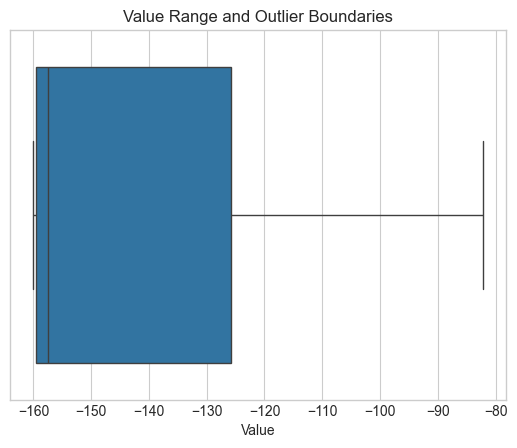

In [48]:
sns.boxplot(x=df['Value'])
plt.title("Value Range and Outlier Boundaries")

The boxplot shows a concentrated cluster near the lower end of the value range with a long upper tail indicating higher-value outliers.

Text(0, 0.5, 'Frequency (Hz)')

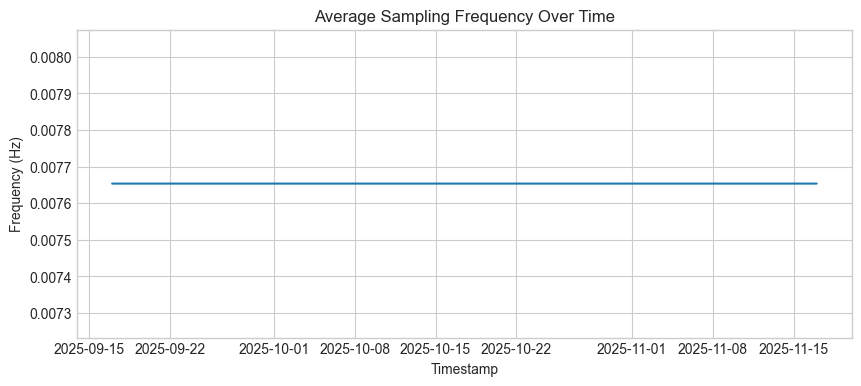

In [49]:
plt.figure(figsize=(10,4))
sns.lineplot(x=df['Timestamp'], y=df['AverageFrequency'])
plt.title("Average Sampling Frequency Over Time")
plt.ylabel("Frequency (Hz)")

The boxplot shows a concentrated cluster near the lower end of the value range with a long upper tail indicating higher-value outliers.

<Axes: >

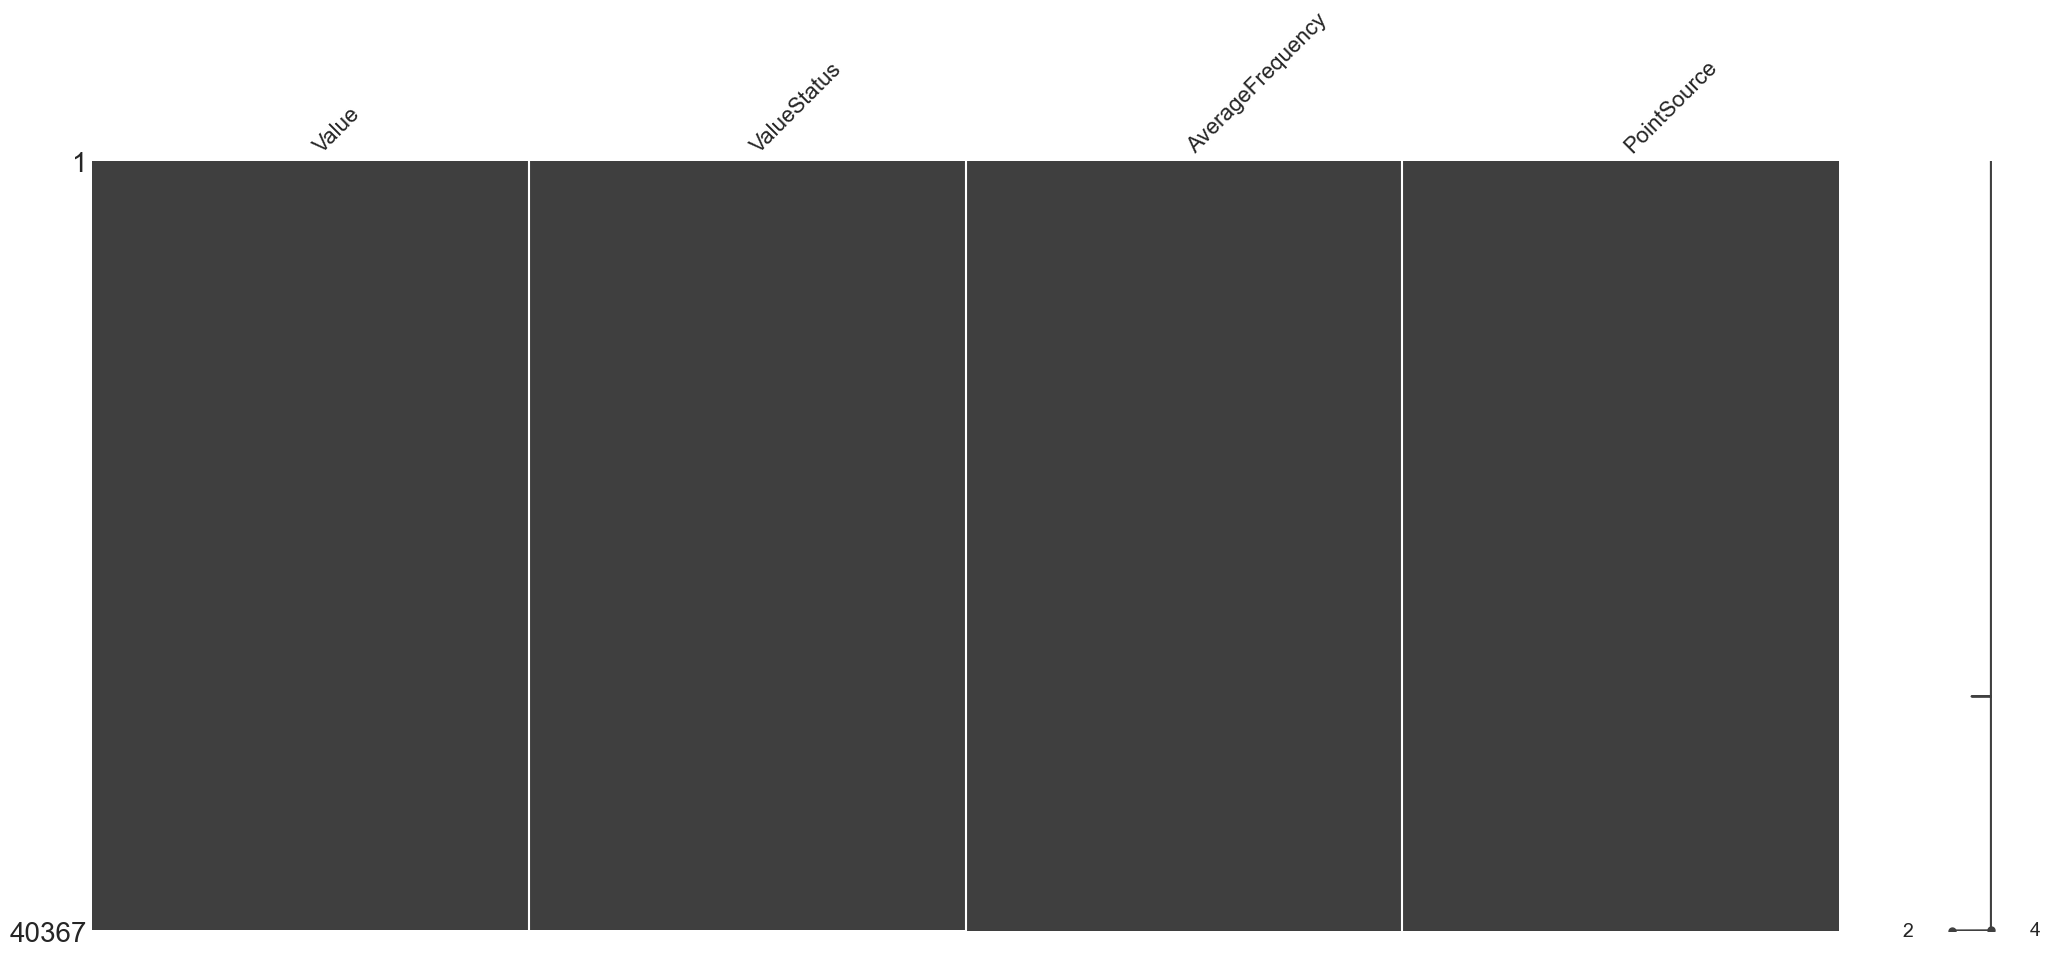

In [50]:
msno.matrix(df[['Value', 'ValueStatus', 'AverageFrequency', 'PointSource']])

The boxplot shows a concentrated cluster near the lower end of the value range with a long upper tail indicating higher-value outliers.

In [51]:
df.groupby('PointSource')['Value'].describe()

,count,mean,std,min,25%,50%,75%,max
PointSource,,,,,,,,
ARANTHERA,40336.0,-141.607392,23.057757,-160.15,-159.62,-157.45,-125.77,-82.09


The boxplot shows a concentrated cluster near the lower end of the value range with a long upper tail indicating higher-value outliers.

Text(0.5, 1.0, 'Value vs. Status Code Relationship')

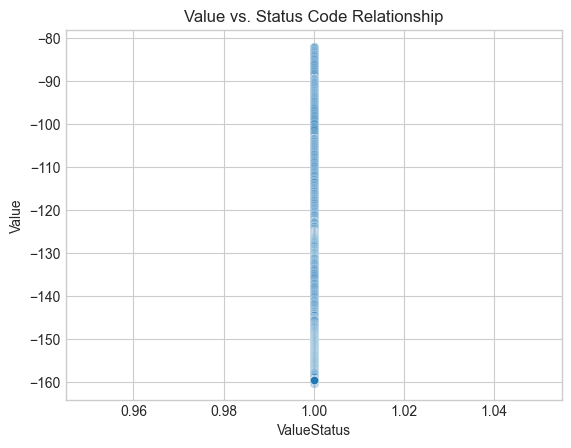

In [52]:
sns.scatterplot(x='ValueStatus', y='Value', data=df, alpha=0.3)
plt.title("Value vs. Status Code Relationship")

The scatter plot shows that all valid readings share the same status code, indicating homogeneous data quality.

Text(0.5, 1.0, 'Hourly Mean Sensor Value')

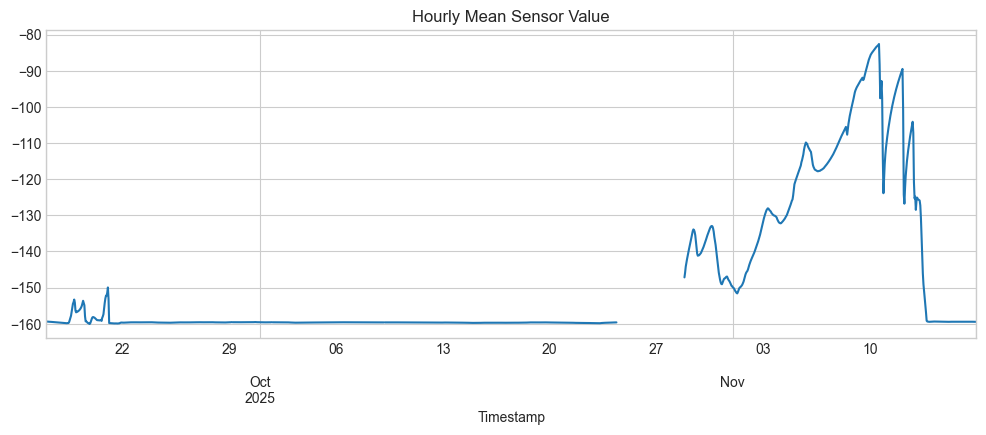

In [53]:
df.set_index('Timestamp')['Value'].resample('H').mean().plot(figsize=(12,4))
plt.title("Hourly Mean Sensor Value")

The hourly mean plot reveals long periods of flat sensor behavior followed by abrupt increases and fluctuations in November.

<Axes: xlabel='ExportType', ylabel='AverageFrequency'>

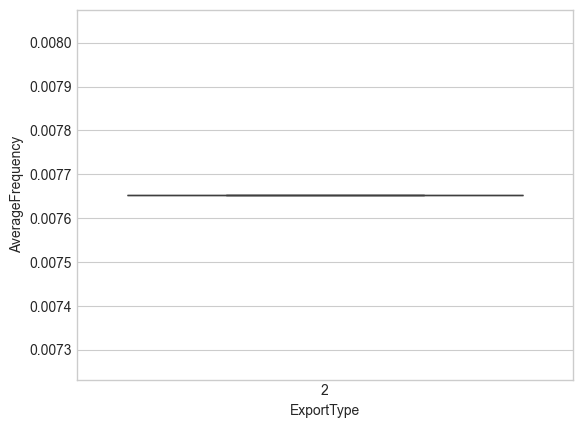

In [54]:
sns.boxplot(x='ExportType', y='AverageFrequency', data=df)

The hourly mean plot reveals long periods of flat sensor behavior followed by abrupt increases and fluctuations in November.

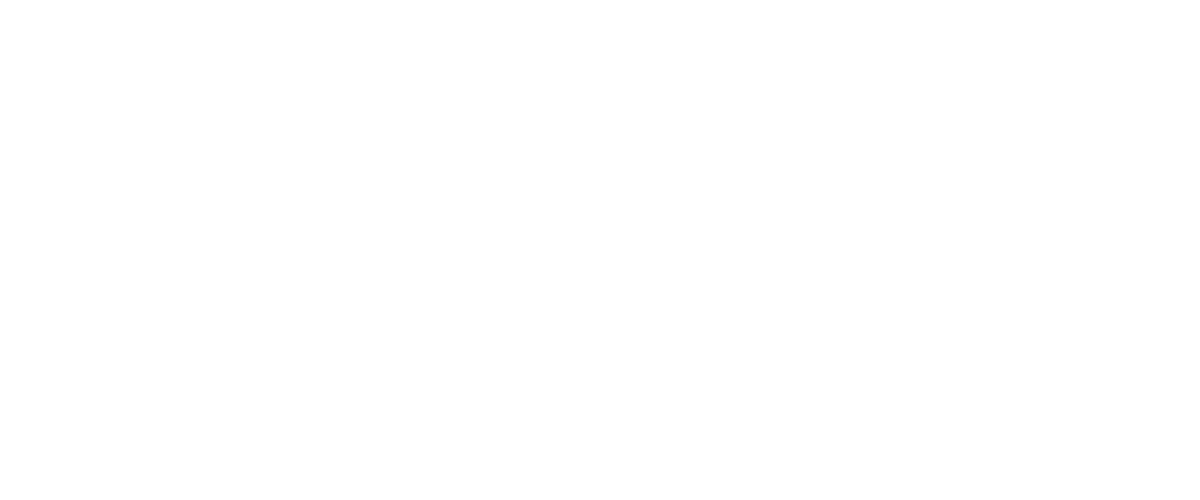

In [55]:
# --- Fix Value column ---
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')  # convert strings → floats
df = df.dropna(subset=['Value', 'Timestamp']).copy()       # drop invalid rows

# --- Convert Timestamp to numeric seconds ---
df['time_numeric'] = pd.to_datetime(df['Timestamp'], errors='coerce').astype('int64') / 1e9

# --- Datashader Plot ---
canvas = ds.Canvas(plot_width=1200, plot_height=500)
agg = canvas.line(df, x='time_numeric', y='Value')
img = tf.shade(agg, cmap=colorcet.fire, how='eq_hist')

tf.set_background(img, "black").to_pil().save("eda_density_fixed.png")
img


The Datashader plot shows the sensor flatlined at −160 dBm for weeks before suddenly rising to −140→−80 dBm in late October, with occasional drops back to −160 indicating outages or invalid readings.

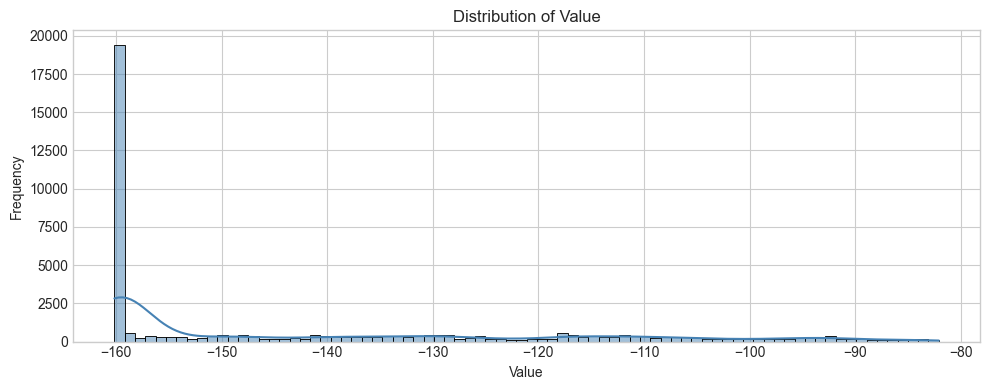

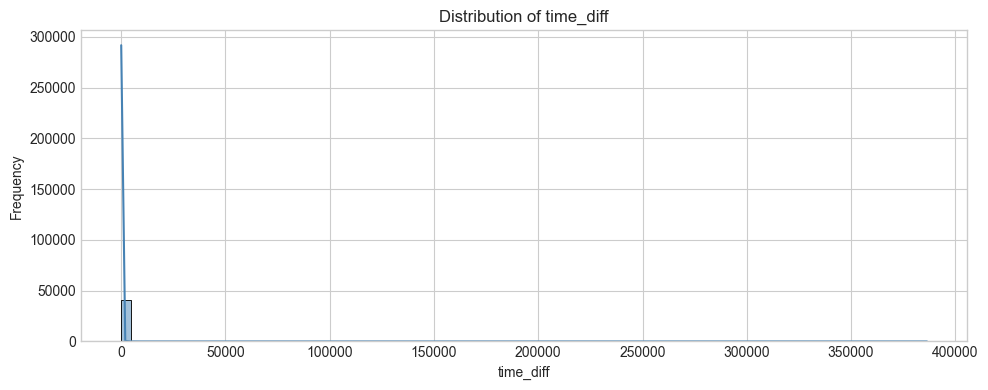

In [56]:
# Convert 'Value' to numeric
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

# Select truly relevant numeric fields
dist_fields = [
    'Value', 
    'ValueStatus', 
    'AverageFrequency', 
    'LowestFrequency', 
    'HighestFrequency', 
    'time_diff'
]

# Drop NaNs
df_clean = df[dist_fields].dropna(how='all')

# --- Distribution plots ---
for col in dist_fields:
    if df_clean[col].dropna().nunique() > 1:
        plt.figure(figsize=(10, 4))
        sns.histplot(df_clean[col], bins=80, kde=True, color='steelblue')
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()


- The value distribution has a massive spike at −160, revealing it as an artificial floor or placeholder, while real measurements are spread thinly between −150 and −90.

- The time-difference histogram shows mostly regular sampling but also several multi-day gaps, indicating large missing periods where the sensor was off or not recording.

In [57]:
# Ensure Value is numeric and Timestamp is datetime
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Drop rows with invalid values
df_clean = df.dropna(subset=['Value', 'Timestamp']).copy()

# --- Define sensible defaults ---
x_col = 'Timestamp'        # time axis for x
y_col = 'Value'            # main sensor measurement
color_col = 'ValueStatus'  # optional color encoding for data quality

# --- Validate that columns exist and are usable ---
if x_col not in df_clean.columns or y_col not in df_clean.columns:
    raise ValueError("Specified x or y column does not exist in DataFrame.")

if not pd.api.types.is_numeric_dtype(df_clean[y_col]):
    raise TypeError(f"Column '{y_col}' must be numeric for hvPlot.")

# --- Interactive hvPlot scatter ---
df_clean.hvplot.scatter(
    x=x_col,
    y=y_col,
    c=color_col if color_col in df_clean.columns else 'blue',
    alpha=0.4,
    width=900,
    height=500,
    title=f"Interactive Scatter: {y_col} over Time",
    xlabel=x_col,
    ylabel=y_col,
    colorbar=True
)


:Scatter   [Timestamp]   (Value,ValueStatus)

## Individual Sensors.


In [ ]:
df1 = pd.read_csv("data/merged_sensor_data.csv")

In [ ]:
def data_overview(df, value_col='Value', time_col='Timestamp'):
    print("=== SHAPE & BASIC INFO ===")
    print(f"Shape: {df.shape}")
    print("\nColumn Types:")
    print(df.dtypes)
    print("\nMemory Usage:")
    print(f"{df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

    print("\n=== SAMPLE DATA ===")
    display(df.head(3))

    print("\n=== DESCRIPTIVE STATISTICS ===")
    display(df.describe(include='all').T)

    print("\n=== UNIQUE VALUE COUNTS ===")
    display(df.nunique().sort_values())

    print("\n=== CONSTANT COLUMNS ===")
    constant_cols = [col for col in df.columns if df[col].nunique() == 1]
    print(constant_cols if constant_cols else "None")

    print("\n=== MISSING VALUES ===")
    missing = df.isna().sum()
    print(missing[missing > 0].sort_values(ascending=False))

    # --- Time and frequency checks ---
    if time_col in df.columns:
        df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
        print("\n=== TIME RANGE ===")
        print(f"Start: {df[time_col].min()} | End: {df[time_col].max()}")
        df['time_diff'] = df[time_col].diff().dt.total_seconds()
        print(f"Sampling Interval (s): mean={df['time_diff'].mean():.2f}, std={df['time_diff'].std():.2f}")

    print("\n=== DUPLICATED TIMESTAMPS ===")
    print(df[time_col].duplicated().sum() if time_col in df.columns else "Timestamp column not found")

    print("\n=== CATEGORICAL VS NUMERIC ===")
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
    print(f"Numeric: {len(num_cols)} columns")
    print(f"Categorical: {len(cat_cols)} columns")

    # --- Visualization-Oriented Downsampling (Datashader) ---
    if time_col in df.columns and value_col in df.columns:
        print("\n=== HIGH-PERFORMANCE VISUALIZATION (Datashader) ===")
        try:
            import datashader as ds
            import datashader.transfer_functions as tf
            from datashader.utils import export_image

            # Ensure numeric + clean datetime
            df[value_col] = pd.to_numeric(df[value_col], errors='coerce')
            df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
            df = df.dropna(subset=[time_col, value_col]).sort_values(by=time_col)

            # Convert timezone-aware datetimes to naive
            df[time_col] = df[time_col].dt.tz_localize(None)

            # Convert datetime to numeric seconds since epoch
            df["time_numeric"] = df[time_col].astype("int64") / 1e9

            cvs = ds.Canvas(plot_width=1000, plot_height=300)
            agg = cvs.line(df, x="time_numeric", y=value_col)
            img = tf.shade(agg, cmap=["lightblue", "navy"], how="eq_hist")
            final_img = tf.set_background(img, "white").to_pil()

            # Save the Datashader image
            final_img.save("data_overview_plot.png")
            print("Datashader visualization saved as 'data_overview_plot.png'")

            # Still show interactively
            final_img.show()

        except Exception as e:
            print("Datashader visualization failed:", e)
            print("→ Falling back to a simple Matplotlib plot.")
            import matplotlib.pyplot as plt
            plt.figure(figsize=(15, 4))
            plt.plot(df[time_col], df[value_col], alpha=0.5)
            plt.title("Simple Fallback Time-Series Plot")
            plt.xlabel(time_col)
            plt.ylabel(value_col)
            plt.tight_layout()
            plt.savefig("simple_fallback_plot.png", dpi=150)
            plt.show()
            print("Saved fallback plot as 'simple_fallback_plot.png'")

    print("\n=== OVERVIEW COMPLETE ===")


In [ ]:
data_overview(df1)

=== SHAPE & BASIC INFO ===
Shape: (3808515, 39)

Column Types:
Timestamp                  object
Value                      object
ValueStatus               float64
ExportDate                 object
ExportVersion              object
ExportType                  int64
TimestampPrecisionType      int64
ExportFrom                 object
ExportTo                   object
IncludeBadValues             bool
TotalEvents                 int64
TotalGoodValues             int64
TotalBadValues              int64
LowestFrequency           float64
HighestFrequency          float64
AverageFrequency          float64
FirstRecordedTimestamp     object
LastRecordedTimestamp      object
ExportedFromServer         object
PiPointName                object
PointSource                object
PointType                  object
DigitalSet                float64
ExceptionDeviation        float64
ExceptionMaximum            int64
ExceptionMinimum            int64
ExceptionPercentage       float64
Descriptor         

,Timestamp,Value,ValueStatus,ExportDate,ExportVersion,ExportType,TimestampPrecisionType,ExportFrom,ExportTo,IncludeBadValues,...,Zero,EngineeringUnits,Compressing,Step,CompressionDeviation,CompressionMaximum,CompressionMinimum,CompressionPercentage,SanitizedFilename,sensor_id
0,2024-01-01T00:00:01.7110137Z,1385.165,1.0,2025-10-06T08:09:02.411285+01:00,1.1.3,2,1,2024-01-01T00:00:00Z,2025-10-05T23:59:59.9999999Z,True,...,0.0,NaN,1,0,0.0,0,0,0.0,LNGMEGIA.CT_TOTALVOL_Meas1_PRIM,LNGMEGIA.CT_TOTALVOL_Meas1_PRIM
1,2024-01-01T00:00:31.7120056Z,1359.986,1.0,2025-10-06T08:09:02.411285+01:00,1.1.3,2,1,2024-01-01T00:00:00Z,2025-10-05T23:59:59.9999999Z,True,...,0.0,NaN,1,0,0.0,0,0,0.0,LNGMEGIA.CT_TOTALVOL_Meas1_PRIM,LNGMEGIA.CT_TOTALVOL_Meas1_PRIM
2,2024-01-01T00:00:46.5100097Z,1338.183,1.0,2025-10-06T08:09:02.411285+01:00,1.1.3,2,1,2024-01-01T00:00:00Z,2025-10-05T23:59:59.9999999Z,True,...,0.0,NaN,1,0,0.0,0,0,0.0,LNGMEGIA.CT_TOTALVOL_Meas1_PRIM,LNGMEGIA.CT_TOTALVOL_Meas1_PRIM



=== DESCRIPTIVE STATISTICS ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,3808515,3808196,; LNGMEGIA.CT_TOTALVOL/Meas1/PRIM,314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Value,3808515.0,909645.0,1929.158,3931.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ValueStatus,3808201.0,NaN,NaN,NaN,0.999921,0.008861,0.0,1.0,1.0,1.0,1.0
ExportDate,3808515,1,2025-10-06T08:09:02.411285+01:00,3808515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ExportVersion,3808515,1,1.1.3,3808515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ExportType,3808515.0,NaN,NaN,NaN,2.0,0.0,2.0,2.0,2.0,2.0,2.0
TimestampPrecisionType,3808515.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
ExportFrom,3808515,1,2024-01-01T00:00:00Z,3808515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ExportTo,3808515,1,2025-10-05T23:59:59.9999999Z,3808515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IncludeBadValues,3808515,1,True,3808515,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== UNIQUE VALUE COUNTS ===


DigitalSet                      0
EngineeringUnits                0
Descriptor                      0
PiPointName                     1
PointType                       1
ExceptionDeviation              1
ExceptionMaximum                1
ExceptionMinimum                1
ExceptionPercentage             1
Span                            1
Zero                            1
Compressing                     1
Step                            1
CompressionDeviation            1
CompressionMaximum              1
CompressionMinimum              1
CompressionPercentage           1
PointSource                     1
SanitizedFilename               1
sensor_id                       1
LastRecordedTimestamp           1
ExportDate                      1
ExportVersion                   1
ExportType                      1
TimestampPrecisionType          1
ExportFrom                      1
ExportedFromServer              1
IncludeBadValues                1
ExportTo                        1
TotalGoodValue


=== CONSTANT COLUMNS ===
['ExportDate', 'ExportVersion', 'ExportType', 'TimestampPrecisionType', 'ExportFrom', 'ExportTo', 'IncludeBadValues', 'TotalEvents', 'TotalGoodValues', 'TotalBadValues', 'LowestFrequency', 'HighestFrequency', 'AverageFrequency', 'FirstRecordedTimestamp', 'LastRecordedTimestamp', 'ExportedFromServer', 'PiPointName', 'PointSource', 'PointType', 'ExceptionDeviation', 'ExceptionMaximum', 'ExceptionMinimum', 'ExceptionPercentage', 'Span', 'Zero', 'Compressing', 'Step', 'CompressionDeviation', 'CompressionMaximum', 'CompressionMinimum', 'CompressionPercentage', 'SanitizedFilename', 'sensor_id']

=== MISSING VALUES ===
DigitalSet          3808515
Descriptor          3808515
EngineeringUnits    3808515
ValueStatus             314
dtype: int64

=== TIME RANGE ===
Start: 2024-01-01 00:00:01.711013700+00:00 | End: 2025-10-05 23:59:45.910003600+00:00
Sampling Interval (s): mean=14.61, std=605.54

=== DUPLICATED TIMESTAMPS ===
319

=== CATEGORICAL VS NUMERIC ===
Numeric: 2

Overview is done here, and one global function was implemented that can be run for all sensors. Next step is EDA. 

In [ ]:
df.describe(include='all')

,Timestamp,Value,ValueStatus,ExportDate,ExportVersion,ExportType,TimestampPrecisionType,ExportFrom,ExportTo,IncludeBadValues,...,Zero,EngineeringUnits,Compressing,Step,CompressionDeviation,CompressionMaximum,CompressionMinimum,CompressionPercentage,SanitizedFilename,sensor_id
count,28196293,28196293.0,2.818959e+07,28196293,28196293,28196293.0,28196293.0,28196293,28196293,28196293,...,28196293.0,0.0,28196293.0,28196293.0,28196293.0,28196293.0,28196293.0,28196293.0,28196293,28196293
unique,12685572,1114467.0,NaN,NaN,1,NaN,NaN,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45,45
top,; LNGMEGIA.CT_TOTALVOL/Meas1/PRIM,0.0,NaN,NaN,1.1.3,NaN,NaN,2024-01-01T00:00:00Z,2025-10-05T23:59:59.9999999Z,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LNGMEGIA.CT_TOTALVOL_Meas1_PRIM,LNGMEGIA.CT_TOTALVOL_Meas1_PRIM
freq,314,68186.0,NaN,NaN,28196293,NaN,NaN,28196293,28196293,28196293,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3808515,3808515
mean,NaN,NaN,9.998227e-01,2025-10-06 08:09:02.411356672+01:00,NaN,2.0,1.0,NaN,NaN,NaN,...,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
min,NaN,NaN,0.000000e+00,2025-10-06 08:09:02.411285+01:00,NaN,2.0,1.0,NaN,NaN,NaN,...,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
25%,NaN,NaN,1.000000e+00,2025-10-06 08:09:02.411284992+01:00,NaN,2.0,1.0,NaN,NaN,NaN,...,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
50%,NaN,NaN,1.000000e+00,2025-10-06 08:09:02.411284992+01:00,NaN,2.0,1.0,NaN,NaN,NaN,...,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
75%,NaN,NaN,1.000000e+00,2025-10-06 08:09:02.411284992+01:00,NaN,2.0,1.0,NaN,NaN,NaN,...,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
max,NaN,NaN,1.000000e+00,2025-10-06 08:09:02.411285+01:00,NaN,2.0,1.0,NaN,NaN,NaN,...,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


In [ ]:
print(df['ValueStatus'].value_counts())

ValueStatus
1.0    28184591
0.0        4999
Name: count, dtype: int64


In [ ]:
print(df['Timestamp'].is_monotonic_increasing)

False


In [ ]:
print(df.isna().sum())

Timestamp                        0
Value                            0
ValueStatus                   6703
ExportDate                       0
ExportVersion                    0
ExportType                       0
TimestampPrecisionType           0
ExportFrom                       0
ExportTo                         0
IncludeBadValues                 0
TotalEvents                      0
TotalGoodValues                  0
TotalBadValues                   0
LowestFrequency                  0
HighestFrequency                 0
AverageFrequency                 0
FirstRecordedTimestamp           0
LastRecordedTimestamp            0
ExportedFromServer               0
PiPointName                      0
PointSource                      0
PointType                        0
DigitalSet                28196293
ExceptionDeviation               0
ExceptionMaximum                 0
ExceptionMinimum                 0
ExceptionPercentage              0
Descriptor                 3808515
Span                

In [ ]:
df.nunique().sort_values()

DigitalSet                       0
EngineeringUnits                 0
CompressionDeviation             1
Zero                             1
Span                             1
ExceptionPercentage              1
ExceptionMinimum                 1
ExceptionMaximum                 1
ExceptionDeviation               1
PointType                        1
PointSource                      1
Step                             1
ExportedFromServer               1
Compressing                      1
ExportFrom                       1
CompressionMaximum               1
CompressionMinimum               1
IncludeBadValues                 1
ExportTo                         1
LowestFrequency                  1
TimestampPrecisionType           1
ExportType                       1
ExportVersion                    1
ExportDate                       1
CompressionPercentage            1
ValueStatus                      2
TotalBadValues                   6
FirstRecordedTimestamp          16
LastRecordedTimestam

Explanation of df.nunique().sort_values():
This shows the number of unique values in each column.
- Columns with 0 or 1 unique value are constant or missing for this sensor/file.
- 'ValueStatus' has 2 unique values (likely 0 and 1: bad/good).
- 'Value' and 'Timestamp' have many unique values, indicating actual sensor readings.
- Most metadata columns (e.g., PiPointName, PointType, EngineeringUnits) are constant for this sensor.
- Use 'Timestamp' for time-based analysis and 'Value' for the actual sensor data.

In [ ]:
# Remove non-timestamp rows before converting to datetime
df = df[df['Timestamp'].str.match(r'^\d{4}-\d{2}-\d{2}T')]  # keep only rows starting with ISO timestamp

df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df['time_diff'] = df['Timestamp'].diff().dt.total_seconds()
print(df['time_diff'].describe())

# Keep only valid readings
df_clean1 = df[df['ValueStatus'] == 1].copy()

# Count duplicates based on Timestamp and Value
num_duplicates = df_clean1.duplicated(subset=['Timestamp', 'Value']).sum()
print("Number of duplicate rows:", num_duplicates)

# Drop duplicates
df_clean1 = df_clean1.drop_duplicates(subset=['Timestamp', 'Value'])

# Count duplicates after dropping
num_duplicates = df_clean1.duplicated(subset=['Timestamp', 'Value']).sum()
print("Number of duplicate rows:", num_duplicates)
df_clean1 = df_clean1.set_index('Timestamp').sort_index()


count    2.818959e+07
mean     1.280283e+00
std      4.870680e+04
min     -5.564160e+07
25%      1.100000e+01
50%      1.500000e+01
75%      4.700099e+01
max      1.221013e+07
Name: time_diff, dtype: float64
Number of duplicate rows: 1218408
Number of duplicate rows: 0


In [ ]:
print(df.describe(include='all'))

                                  Timestamp       Value   ValueStatus  \
count                              28189590  28189590.0  2.818959e+07   
unique                                  NaN   1114466.0           NaN   
top                                     NaN         0.0           NaN   
freq                                    NaN     68186.0           NaN   
mean    2025-01-21 00:38:58.473093376+00:00         NaN  9.998227e-01   
min     2024-01-01 00:00:01.711013700+00:00         NaN  0.000000e+00   
25%     2024-10-11 20:54:28.122009088+00:00         NaN  1.000000e+00   
50%     2024-12-26 06:50:14.765007104+00:00         NaN  1.000000e+00   
75%     2025-03-22 21:06:29.620753920+00:00         NaN  1.000000e+00   
max        2025-10-05 23:59:59.123001+00:00         NaN  1.000000e+00   
std                                     NaN         NaN  1.331554e-02   

                                 ExportDate ExportVersion  ExportType  \
count                              28189590      2

## Next

1. Prepare new incoming data using the same preprocessing pipeline (pivot, fill, standardize with original scaler).

2. Split the new dataset into two subsets:

    - Dataset A (Calibration): clean-ish portion for evaluating each model individually.

    - Dataset B (Stress Test): contains anomalies, gaps, and drift for hybrid model robustness testing.

3. Evaluate each model separately (Autoencoder, Regression, GRU), generating reconstruction errors, forecast residuals, and predicted SRI.

4. Compute the Hybrid Health Confidence Score (HCS) on both datasets and compare stability, drift detection, and anomaly sensitivity.

5. Analyze performance metrics (MSE, drift detection accuracy, false positives/negatives).

6. Perform targeted fine-tuning only if a specific model underperforms, keeping the hybrid weights fixed.

7. Package all trained models, scalers, thresholds, and inference logic into a deployable health monitoring pipeline.

8. Extend the system with sensor-level and cluster-level diagnostics for deeper interpretability and root-cause analysis.

## Light Preprocessing

In [60]:
# Configurations

RAW_PATH = "/Users/yasmine/Kongsberg/data/testing/test_data.csv"
OUTPUT_CLEAN = "/Users/yasmine/Kongsberg/data/testing/cleaned_test_data.csv"
OUTPUT_SEQ = "/Users/yasmine/Kongsberg/data/testing/cleaned_sequences.npy"

SEQ_LEN = 10   # GRU / AE sequence length

In [61]:
# Load uncleaned dataset
print("Loading uncleaned test dataset...")
df = pd.read_csv(RAW_PATH)

# Ensure timestamp column is named consistently
timestamp_col = [c for c in df.columns if "time" in c.lower()][0]
df[timestamp_col] = pd.to_datetime(df[timestamp_col])

# Sort chronologically
df = df.sort_values(timestamp_col)

Loading uncleaned test dataset...


ValueError: time data "; LNGMEGIA.CT027/Meas1/PRIM" doesn't match format "%Y-%m-%dT%H:%M:%S.%f%z", at position 390565. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
# 2. PIVOT TO SENSOR × TIMESTAMP SHAPE
print("Pivoting...")
if "sensor" in df.columns and "value" in df.columns:
    pivot_df = df.pivot(index=timestamp_col, columns="sensor", values="value")
else:
    # assume every column except timestamp is sensor
    pivot_df = df.set_index(timestamp_col)